In [1]:
import torch
import torchvision
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch import optim

In [2]:
print(torch.__version__)

2.10.0+cu128


In [ ]:
print(torchvision.__version__)

0.25.0+cu128


In [4]:
train_data = datasets.FashionMNIST(
        root="cnndata",
        train=True,
        download=True,
        transform=ToTensor(),
        target_transform=None
    )
test_data = datasets.FashionMNIST(
        root="cnndata",
        train=False,
        download=True,
        transform=ToTensor(),
        target_transform=None
    )

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 185kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [9]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

Text(0.5, 1.0, '9')

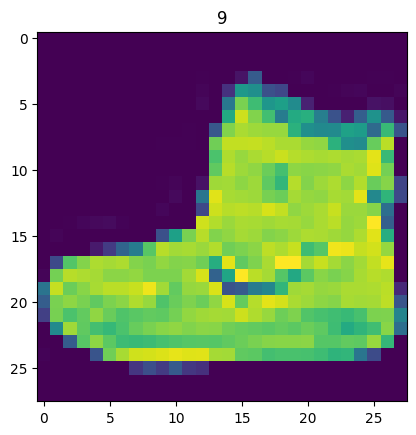

In [10]:
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

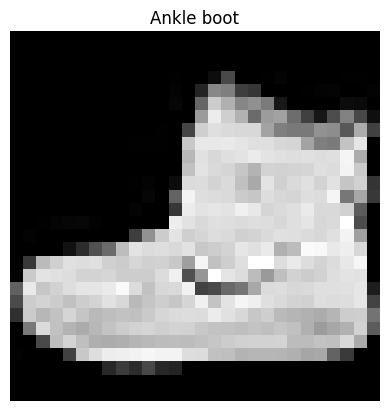

In [11]:
class_names = train_data.classes
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

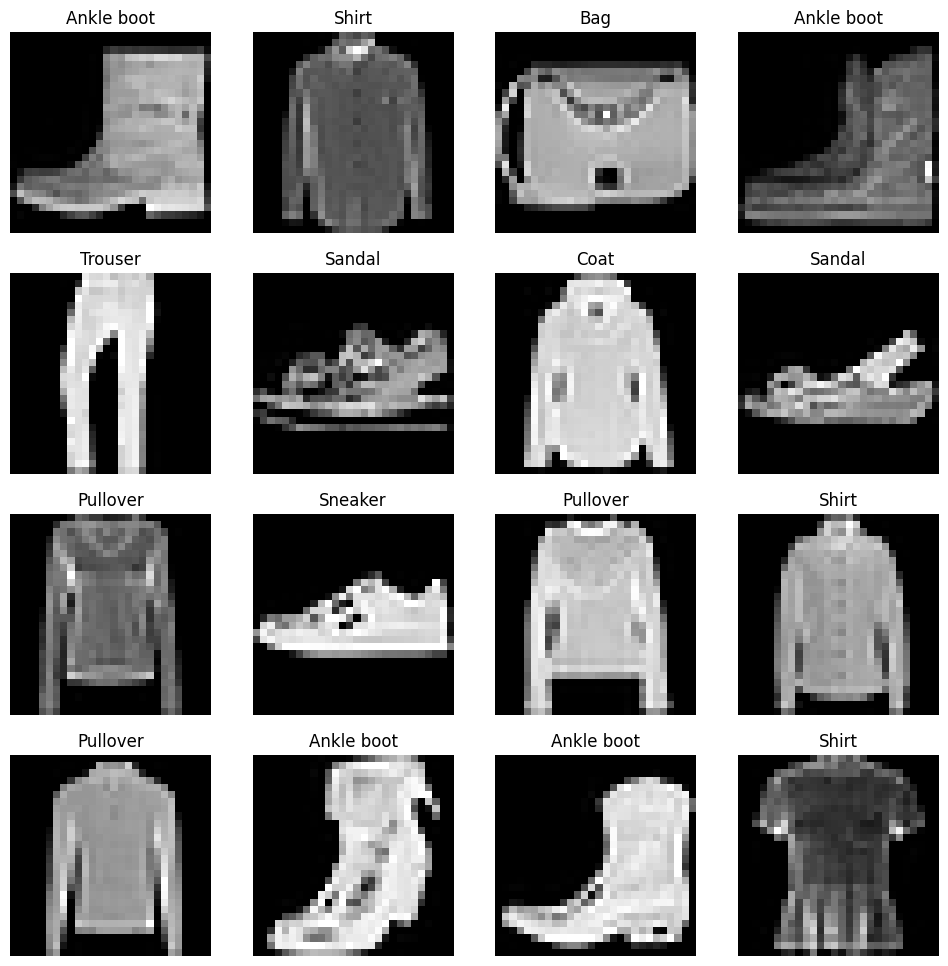

In [12]:
torch.manual_seed(42)
fig = plt.figure(figsize=(12,12))
rows, cols = 4,4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [13]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

In [14]:
len(train_dataloader)

1875

In [15]:
train_features, train_labels = next(iter(train_dataloader))
test_features, test_labels = next(iter(test_dataloader))

torch.Size([1, 28, 28])
tensor(1)


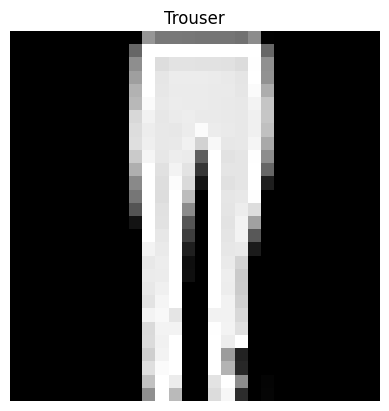

In [16]:
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features), size=[1]).item()
img, label = train_features[random_idx], train_labels[random_idx]
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)
print(img.shape)
print(label)

In [17]:
flatten_model = nn.Flatten()
x = train_features[0]

op=flatten_model(x)
x.shape # -> [channel, height, width]

torch.Size([1, 28, 28])

In [18]:
op.shape # -> [channel, height*width]

torch.Size([1, 784])

In [ ]:
op.squeeze()

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078,
        0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2863, 0.0000, 0.0000, 0.0078, 

In [20]:
class damodel(nn.Module):
    def __init__(self, input, hidden_units, output):
        super().__init__()
        self.model = nn.Sequential(
                nn.Flatten(),
                nn.Linear(input, hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, output),
                
            )
    def forward(self, x):
        return self.model(x)

In [21]:
torch.manual_seed(42)
model_0 = damodel(784, 256, len(class_names)) # o/p is 10 
device = "cuda" if torch.cuda.is_available() else "cpu"

model_0.to(device)


damodel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [22]:
LR = 0.1
optimizer = optim.SGD(params=model_0.parameters(), lr = LR)
criterion = nn.CrossEntropyLoss()

In [24]:
import os
print(os.uname())

posix.uname_result(sysname='Linux', nodename='d244cb1d9f06', release='6.6.113+', version='#1 SMP Mon Feb  2 12:27:57 UTC 2026', machine='x86_64')


In [25]:
EPOCHS = 100
for epoch in range(EPOCHS):
    total_epoch_loss = 0
    for features, label in train_dataloader:
        features, label = features.to(device), label.to(device)

        output = model_0(features)

        loss = criterion(output, label)

        optimizer.zero_grad()

        loss.backward()
       
        optimizer.step()
        total_epoch_loss+=loss.item()

    avg_epoch_loss = total_epoch_loss / len(train_dataloader)
    print(f"Epoch : {epoch+1}  : Loss {avg_epoch_loss}")

Epoch : 1  : Loss 0.26257806897560754
Epoch : 2  : Loss 0.2529457040190697
Epoch : 3  : Loss 0.24568600976467134
Epoch : 4  : Loss 0.23676328173875807
Epoch : 5  : Loss 0.23145779987970988
Epoch : 6  : Loss 0.22613500225245953
Epoch : 7  : Loss 0.22180269021391869
Epoch : 8  : Loss 0.21468179674496254
Epoch : 9  : Loss 0.2099432486365239
Epoch : 10  : Loss 0.2046653759613633
Epoch : 11  : Loss 0.20039101702421905
Epoch : 12  : Loss 0.194974922597905
Epoch : 13  : Loss 0.18984029049475987
Epoch : 14  : Loss 0.18679359014133612
Epoch : 15  : Loss 0.1828036674340566
Epoch : 16  : Loss 0.1765661814113458
Epoch : 17  : Loss 0.17409923958082993
Epoch : 18  : Loss 0.17010138208617767
Epoch : 19  : Loss 0.16610029817471902
Epoch : 20  : Loss 0.16389103057583174
Epoch : 21  : Loss 0.15842584808965524
Epoch : 22  : Loss 0.15682878529056907
Epoch : 23  : Loss 0.1537299578030904
Epoch : 24  : Loss 0.14979688961903254
Epoch : 25  : Loss 0.14761738458424806
Epoch : 26  : Loss 0.14398145325730244
Epo

In [31]:
model_0.eval()
total, correct= 0, 0
with torch.inference_mode():
    for features, labels in test_dataloader:
        features, labels = features.to(device), labels.to(device)

        output = model_0(features)
        loss+= criterion(output, labels).item()
        total += labels.shape[0]
        correct += (output.argmax(dim = 1) == labels).sum().item()

    acc = correct/total
    print(f"acc:{acc}")
        

acc:0.8949
